# 🚕 260205_데이터클리닝_택시요금데이터

In [297]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('trip.csv')

## 1. 데이터 확인하기

In [298]:
data.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [299]:
data.tail()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
22696,Austin Johnson,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,Cash,3,0.61,4.0,0.00,0.00
22697,Monique Williams,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,Cash,1,16.71,52.0,14.64,5.76
22698,Drew Graves,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,Debit Card,1,0.42,4.5,0.00,0.00
22699,Jonathan Copeland,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,Debit Card,1,2.36,10.5,1.70,0.00
22700,Benjamin Miller,03/02/2017 1:02:49 PM,03/02/2017 1:16:09 PM,Cash,1,2.10,11.0,2.35,0.00


In [300]:
data.shape

(22701, 9)

In [301]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


In [302]:
data.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22701.000000,22701.000000,22698.000000,22701.000000,22701.000000
mean,1.643584,2.913400,13.024009,1.835745,0.312514
std,1.304942,3.653023,13.240074,2.800537,1.399153
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


## 2. 결측치 판단 및 처리

In [303]:
data.isna().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              3
tip_amount               0
tolls_amount             0
dtype: int64

In [304]:
data.isna().mean()

passenger_name           0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
payment_method           0.000000
passenger_count          0.000000
trip_distance            0.000000
fare_amount              0.000132
tip_amount               0.000000
tolls_amount             0.000000
dtype: float64

In [305]:
data['fare_amount'].sort_values()

12946   -120.00
11206     -4.50
20700     -4.50
17604     -4.00
14716     -4.00
          ...  
20314    450.00
8478     999.99
52          NaN
189         NaN
244         NaN
Name: fare_amount, Length: 22701, dtype: float64

In [306]:
data[data['fare_amount'].isna()]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
52,Benjamin Johnson,04/04/2017 4:22:03 PM,04/04/2017 4:35:30 PM,Cash,1,2.20,NaN,0.0,0.00
189,Maria Ibarra,08/21/2017 12:40:25 PM,08/21/2017 1:12:31 PM,Debit Card,3,15.20,NaN,5.0,0.00
244,Tina Avila,08/09/2017 8:32:09 AM,08/09/2017 9:31:11 AM,Cash,1,15.89,NaN,10.0,5.76


In [307]:
data['fare_amount'].mean()

np.float64(13.024009163802976)

In [308]:
data['fare_amount'].median()

9.5

In [309]:
data['fare_amount'] = data['fare_amount'].fillna(data['fare_amount'].median())
data[data['fare_amount'].isna()]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount


In [310]:
data.isna().sum()

passenger_name           0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
payment_method           0
passenger_count          0
trip_distance            0
fare_amount              0
tip_amount               0
tolls_amount             0
dtype: int64

### 🧩 결측치 채우기  
fare_amount 기본요금에 이상치가 있어 평균값이 많이 올라가있어 중앙값으로 결측치 처리함

## 3. 이상치 판단 및 처리

### fare_amount : 기본요금 (팁, 톨게이트 비용 제외하고 순수 택시 요금)

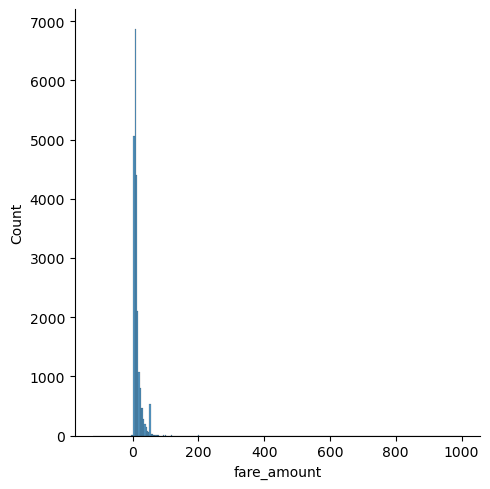

In [311]:
sns.displot(data['fare_amount'])

<Axes: ylabel='fare_amount'>

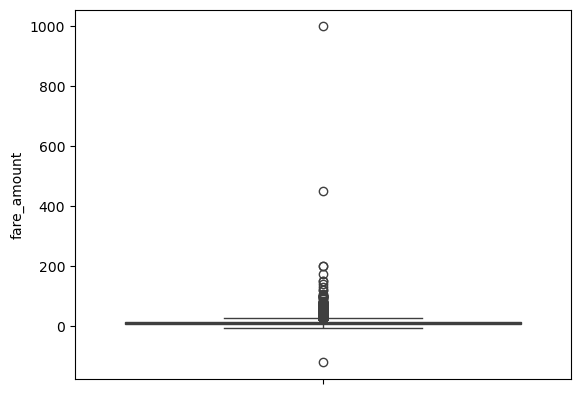

In [312]:
sns.boxplot(data['fare_amount'])

<Axes: xlabel='None', ylabel='fare_amount'>

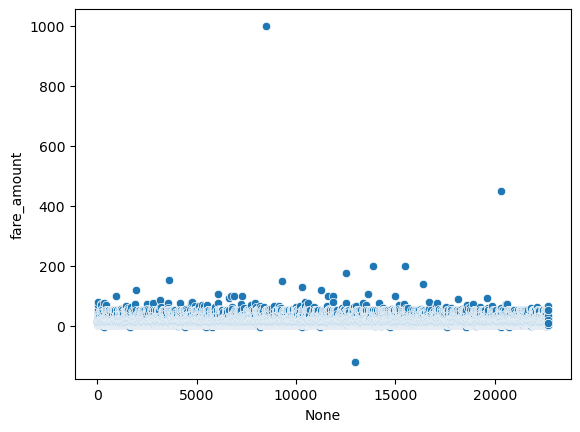

In [313]:
sns.scatterplot(x=data.index, y=data['fare_amount'])

In [314]:
data['fare_amount'].sort_values()

12946   -120.00
11206     -4.50
20700     -4.50
14716     -4.00
17604     -4.00
          ...  
12513    175.00
15476    200.00
13863    200.01
20314    450.00
8478     999.99
Name: fare_amount, Length: 22701, dtype: float64

In [315]:
data.loc[data['fare_amount'] >= 200]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
8478,Alexis Hanson,02/06/2017 5:50:10 AM,02/06/2017 5:51:08 AM,Credit Card,1,2.60,999.99,200.00,0.00
13863,William Yates,05/19/2017 8:20:21 AM,05/19/2017 9:20:30 AM,Credit Card,1,33.92,200.01,51.64,5.76
15476,James Dyer MD,06/06/2017 8:55:01 PM,06/06/2017 8:55:06 PM,Debit Card,1,0.00,200.00,11.00,0.00
20314,Nicholas Thomas,12/19/2017 9:40:46 AM,12/19/2017 9:40:55 AM,Cash,2,0.00,450.00,0.00,0.00


#### ⚠️ 이상치 발견!
IQR 방법으로 위아래 1.5배가 넘어가는 데이터 삭제  
그리고 기본요금인데 0원이랑 -요금들을 확인하여 삭제함

In [316]:
Q1 = data['fare_amount'].quantile(0.25)
Q3 = data['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [317]:
data[(data['fare_amount'] < lower) | (data['fare_amount'] > upper)]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
6,Tonya Moreno,05/03/2017 7:04:09 PM,05/03/2017 8:03:47 PM,Cash,1,12.83,47.50,9.86,0.00
11,Jamie Brown,03/05/2017 7:15:30 PM,03/05/2017 7:52:18 PM,Debit Card,2,18.90,52.00,14.58,5.54
22,Jacqueline Mclean DVM,10/11/2017 12:34:49 PM,10/11/2017 1:22:38 PM,Debit Card,1,12.30,68.25,12.00,16.26
30,David Burton,11/06/2017 8:30:50 PM,11/07/2017 12:00:00 AM,Credit Card,1,30.83,80.00,18.56,11.52
33,Amy Larsen,07/26/2017 11:26:50 PM,07/26/2017 11:55:49 PM,Cash,1,14.32,40.50,0.00,0.00
...,...,...,...,...,...,...,...,...,...
22647,Jaime Calderon,07/10/2017 10:56:44 PM,07/10/2017 11:25:16 PM,Cash,1,7.90,27.50,2.00,0.00
22670,Shirley Ferguson,02/22/2017 6:45:04 AM,02/22/2017 7:19:34 AM,Debit Card,5,25.30,67.50,17.08,0.00
22678,Ricardo Peterson,12/14/2017 12:21:01 PM,12/14/2017 12:56:21 PM,Cash,1,9.47,32.00,6.00,5.76
22688,Madison Harrell,02/08/2017 6:13:26 PM,02/08/2017 7:34:11 PM,Credit Card,5,10.64,52.00,14.84,5.54


<Axes: ylabel='fare_amount'>

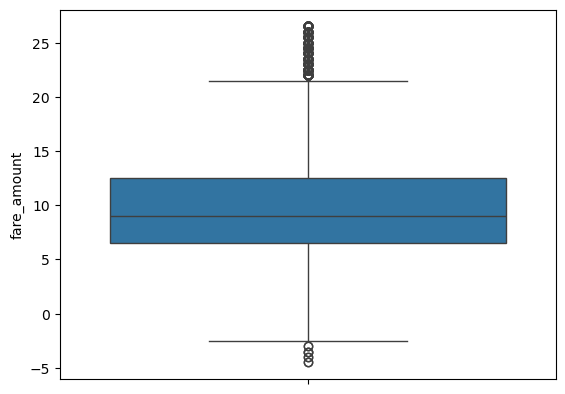

In [318]:
data = data[(data['fare_amount'] >= lower) & (data['fare_amount'] <= upper)]
sns.boxplot(data['fare_amount'])

In [319]:
data.loc[data['fare_amount'] <= 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
316,Tiffany Johnson,12/13/2017 2:02:39 AM,12/13/2017 2:03:08 AM,Cash,6,0.12,-2.5,0.0,0.0
1648,Debbie Holmes,07/05/2017 11:02:23 AM,07/05/2017 11:03:00 AM,Credit Card,1,0.04,-2.5,0.0,0.0
4404,Mrs. Tiffany Brown DDS,12/20/2017 4:06:53 PM,12/20/2017 4:47:50 PM,Cash,1,7.06,0.0,0.0,0.0
4425,Bobby Wilson,11/16/2017 8:13:30 PM,11/16/2017 8:14:50 PM,Cash,2,0.06,-3.0,0.0,0.0
5450,Alejandro Williams,04/06/2017 12:50:26 PM,04/06/2017 12:52:39 PM,Debit Card,1,0.25,-3.5,0.0,0.0
5724,William Holland,06/12/2017 12:08:55 PM,06/12/2017 12:08:57 PM,Debit Card,1,0.00,0.0,0.0,0.0
5760,Samuel Cooper,01/03/2017 8:15:23 PM,01/03/2017 8:15:39 PM,Debit Card,1,0.02,-2.5,0.0,0.0
8206,Stephanie Summers,10/28/2017 8:39:36 PM,10/28/2017 8:41:59 PM,Credit Card,1,0.41,-3.5,0.0,0.0
10283,Donna Larson,06/05/2017 5:34:25 PM,06/05/2017 5:36:29 PM,Credit Card,2,0.00,-2.5,0.0,0.0
10508,Travis Vega,03/30/2017 3:14:26 AM,03/30/2017 3:14:28 AM,Debit Card,1,0.00,0.0,0.0,0.0


<Axes: ylabel='fare_amount'>

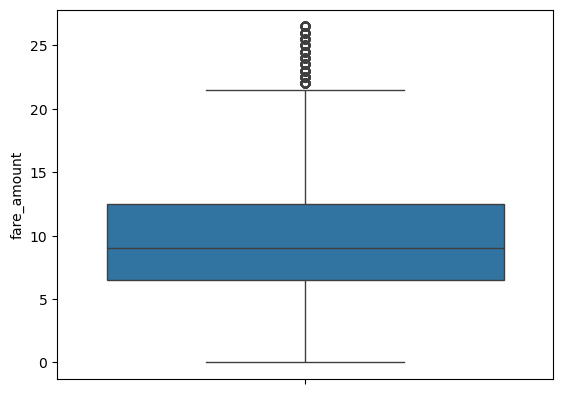

In [320]:
data = data[data['fare_amount'] > 0]
sns.boxplot(data['fare_amount'])

### passenger_count : 승객 수

<Axes: xlabel='None', ylabel='passenger_count'>

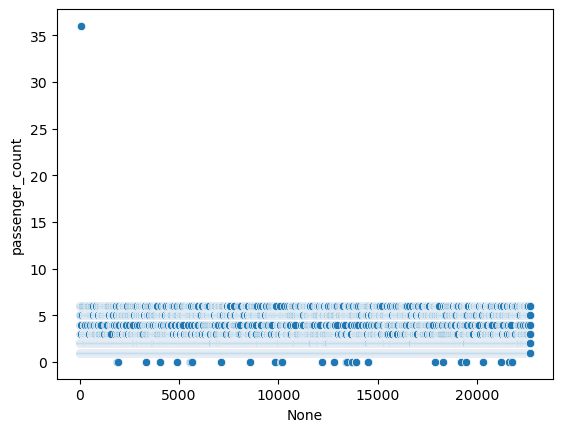

In [321]:
sns.scatterplot(x=data.index, y=data['passenger_count'])

In [322]:
data.loc[data['passenger_count'] <= 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
1876,Tommy Weaver,12/03/2017 12:05:52 PM,12/03/2017 12:13:51 PM,Cash,0,1.1,7.0,0.00,0.0
1927,Melissa Thompson,09/09/2017 3:44:45 AM,09/09/2017 3:49:19 AM,Cash,0,0.8,5.0,0.00,0.0
3354,Lisa Wilson,12/18/2017 10:44:57 PM,12/18/2017 11:00:24 PM,Cash,0,2.7,12.5,2.75,0.0
4062,Benjamin Anderson,11/27/2017 1:08:01 PM,11/27/2017 1:17:55 PM,Debit Card,0,1.7,9.0,1.95,0.0
4921,Austin Gutierrez,12/16/2017 2:59:17 PM,12/16/2017 3:21:59 PM,Debit Card,0,3.1,15.5,4.05,0.0
5565,Charles Stewart,09/04/2017 5:40:00 PM,09/04/2017 5:51:52 PM,Cash,0,1.3,9.0,1.95,0.0
5605,Kristina Smith,12/17/2017 12:18:49 PM,12/17/2017 12:40:45 PM,Cash,0,4.2,18.0,3.75,0.0
5670,Susan Cook,12/16/2017 7:50:12 PM,12/16/2017 8:00:30 PM,Cash,0,1.0,8.0,1.50,0.0
7104,Latasha Campbell,12/29/2017 1:41:17 PM,12/29/2017 1:55:57 PM,Cash,0,2.1,11.5,2.45,0.0
8597,Jennifer Park,11/14/2017 12:06:01 PM,11/14/2017 12:27:38 PM,Debit Card,0,7.0,23.5,6.05,0.0


In [323]:
data.loc[data['passenger_count'] > 35]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
64,Manuel Dickson,10/05/2017 9:39:28 AM,10/05/2017 9:42:32 AM,Debit Card,36,0.22,21.5,0.0,0.0


#### ⚠️ 이상치 발견!
택시 승객 수가 36명...? 관광버스도 아니고...  
그리고 0명? 유령택시도 아니고...  
다 삭제!

<Axes: ylabel='passenger_count'>

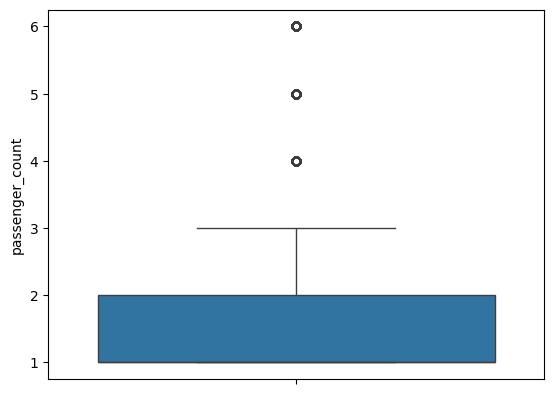

In [324]:
data = data[(data['passenger_count'] > 0) & (data['passenger_count'] < 35)]
sns.boxplot(data['passenger_count'])

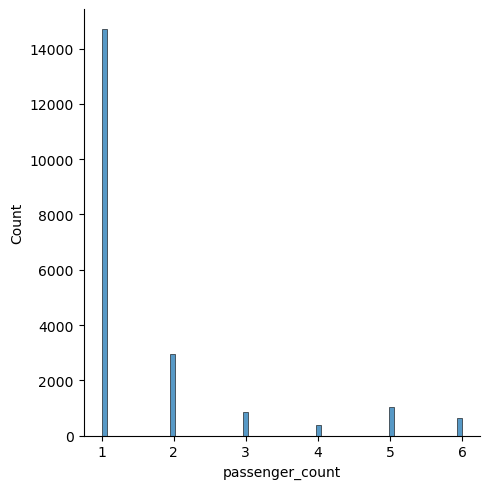

In [325]:
sns.displot(data['passenger_count'])

### trip_distance : 이동 거리

<Axes: xlabel='None', ylabel='trip_distance'>

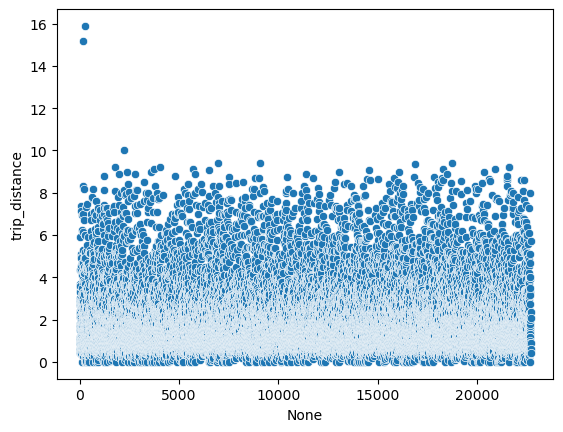

In [326]:
sns.scatterplot(x=data.index, y=data['trip_distance'])

<Axes: ylabel='trip_distance'>

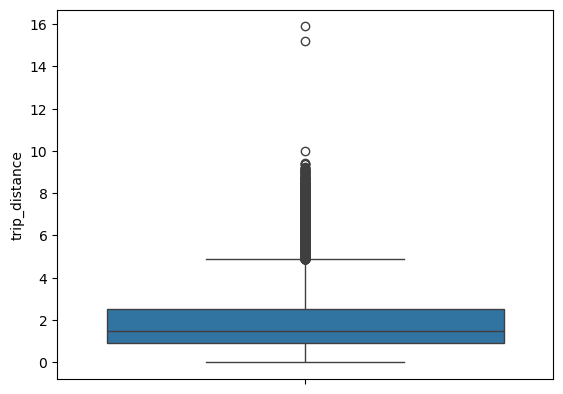

In [327]:
sns.boxplot(data['trip_distance'])

In [328]:
data.loc[data['trip_distance'] <= 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
129,Linda Kaufman,06/22/2017 8:05:33 AM,06/22/2017 8:05:40 AM,Debit Card,1,0.0,20.0,0.00,0.0
248,Erik Perez,09/18/2017 8:50:53 PM,09/18/2017 8:51:03 PM,Cash,1,0.0,2.5,0.00,0.0
293,Deborah Sanford,10/04/2017 7:46:24 PM,10/04/2017 7:46:50 PM,Cash,1,0.0,2.5,0.00,0.0
321,Ryan Hughes,02/22/2017 4:01:44 AM,02/22/2017 4:01:53 AM,Cash,1,0.0,2.5,0.00,0.0
426,David Parker,01/14/2017 7:00:26 AM,01/14/2017 7:00:53 AM,Cash,1,0.0,2.5,6.70,0.0
...,...,...,...,...,...,...,...,...,...
22028,Eduardo Jenkins,07/27/2017 7:44:24 AM,07/27/2017 7:44:24 AM,Credit Card,1,0.0,10.5,0.00,0.0
22192,Angela French,10/16/2017 8:34:07 AM,10/16/2017 8:34:10 AM,Credit Card,1,0.0,2.5,0.00,0.0
22327,Kelsey Rogers,07/21/2017 11:30:29 PM,07/21/2017 11:31:12 PM,Debit Card,1,0.0,16.8,3.42,0.0
22385,Joseph Castillo,01/07/2017 4:48:42 AM,01/07/2017 4:51:03 AM,Cash,1,0.0,10.0,0.00,0.0


In [329]:
data = data[data['trip_distance'] > 0]

In [330]:
data.loc[data['trip_distance'] <= 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount


#### ⚠️ 이상치 발견!
이동거리가 0? 택시가 출발을 안한거임  
당장 삭제!

### tip_amount : 팁 금액

<Axes: xlabel='None', ylabel='tip_amount'>

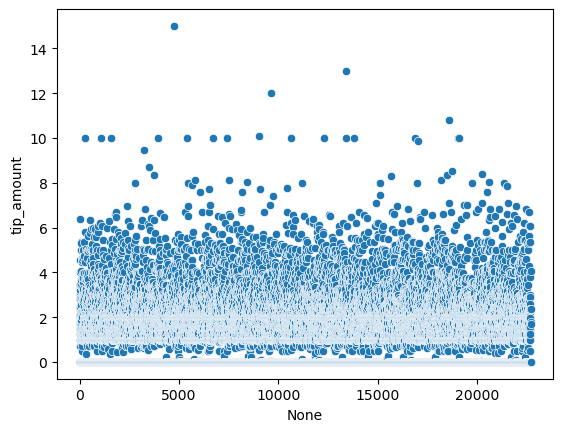

In [331]:
sns.scatterplot(x=data.index, y=data['tip_amount'])

In [332]:
data['tip_amount'].sort_values()

20169     0.00
19991     0.00
9562      0.00
9564      0.00
9565      0.00
         ...  
9002     10.07
18599    10.80
9633     12.00
13388    13.00
4730     15.00
Name: tip_amount, Length: 20484, dtype: float64

#### 📌 이상치 노발견!
팁 이정도 주는건 그럴 수 있다 생각  
그리고 팁이니까 0도 가능하다는 생각  
따로 이상치 처리 안함!

### tolls_amount : 톨게이트(유료도로) 요금

<Axes: xlabel='None', ylabel='tolls_amount'>

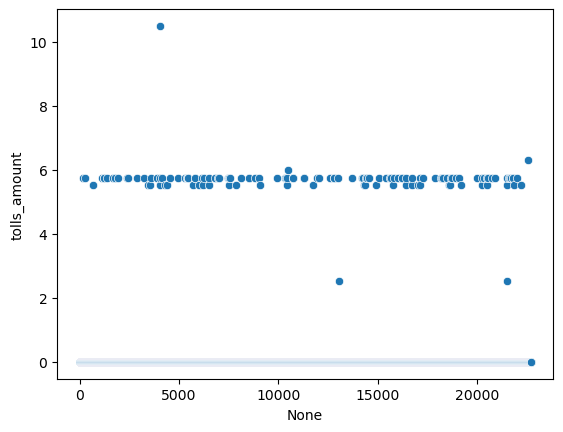

In [333]:
sns.scatterplot(x=data.index, y=data['tolls_amount'])

In [334]:
data['tolls_amount'].sort_values()

0         0.00
15126     0.00
15125     0.00
15124     0.00
15123     0.00
         ...  
5476      5.76
21626     5.76
10478     6.00
22563     6.32
4063     10.50
Name: tolls_amount, Length: 20484, dtype: float64

#### 📌 이상치 노발견!
유료도로 안지나갔으면 0원 가능  
지난친 금액도 없다고 판단  
따로 이상치 처리 안함!

## 4. 택시 탑승 및 하차 시간을 활용
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?

In [335]:
from datetime import datetime

In [336]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20484 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         20484 non-null  object 
 1   tpep_pickup_datetime   20484 non-null  object 
 2   tpep_dropoff_datetime  20484 non-null  object 
 3   payment_method         20484 non-null  object 
 4   passenger_count        20484 non-null  int64  
 5   trip_distance          20484 non-null  float64
 6   fare_amount            20484 non-null  float64
 7   tip_amount             20484 non-null  float64
 8   tolls_amount           20484 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


In [337]:
data.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [338]:
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])

In [339]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20484 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   passenger_name         20484 non-null  object        
 1   tpep_pickup_datetime   20484 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  20484 non-null  datetime64[ns]
 3   payment_method         20484 non-null  object        
 4   passenger_count        20484 non-null  int64         
 5   trip_distance          20484 non-null  float64       
 6   fare_amount            20484 non-null  float64       
 7   tip_amount             20484 non-null  float64       
 8   tolls_amount           20484 non-null  float64       
dtypes: datetime64[ns](2), float64(4), int64(1), object(2)
memory usage: 1.6+ MB


In [340]:
data['ride_duration_min'] = (data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']).dt.total_seconds() / 60

In [341]:
data.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,ride_duration_min
0,Pamela Duffy,2017-03-25 08:55:43,2017-03-25 09:09:47,Debit Card,6,3.34,13.0,2.76,0.0,14.066667
1,Michelle Foster,2017-04-11 14:53:28,2017-04-11 15:19:58,Debit Card,1,1.80,16.0,4.00,0.0,26.500000
2,Tina Combs,2017-12-15 07:26:56,2017-12-15 07:34:08,Debit Card,1,1.00,6.5,1.45,0.0,7.200000
3,Anthony Ray,2017-05-07 13:17:59,2017-05-07 13:48:14,Cash,1,3.70,20.5,6.39,0.0,30.250000
4,Brianna Johnson,2017-04-15 23:32:20,2017-04-15 23:49:03,Debit Card,1,4.37,16.5,0.00,0.0,16.716667


In [342]:
data[data['ride_duration_min'] <= 0]

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,ride_duration_min


<Axes: ylabel='ride_duration_min'>

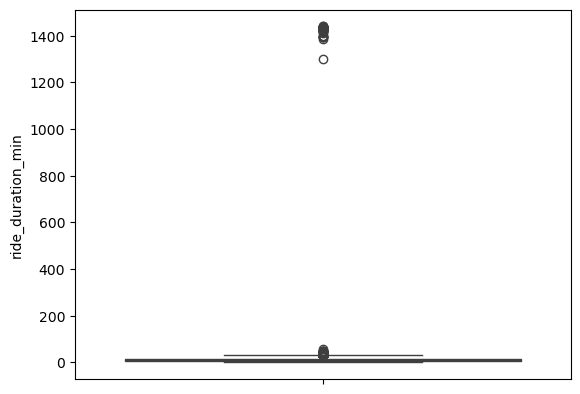

In [343]:
sns.boxplot(data['ride_duration_min'])

<Axes: xlabel='ride_duration_min', ylabel='trip_distance'>

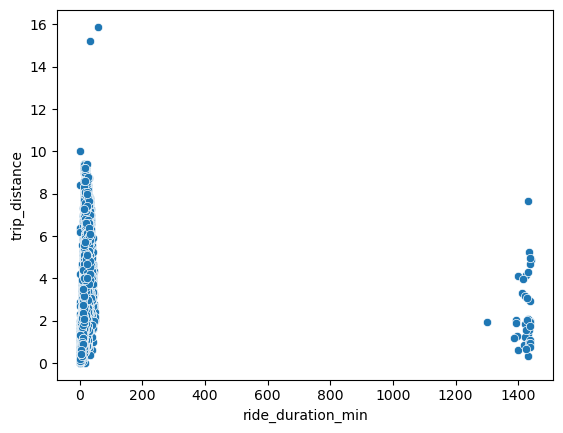

In [344]:
sns.scatterplot(x= data['ride_duration_min'], y=data['trip_distance'])

#### ⚠️ 이상치 발견!
택시를 탄 시간이 1400분...? 거의 23시간...?  
당장 제거!

<Axes: ylabel='ride_duration_min'>

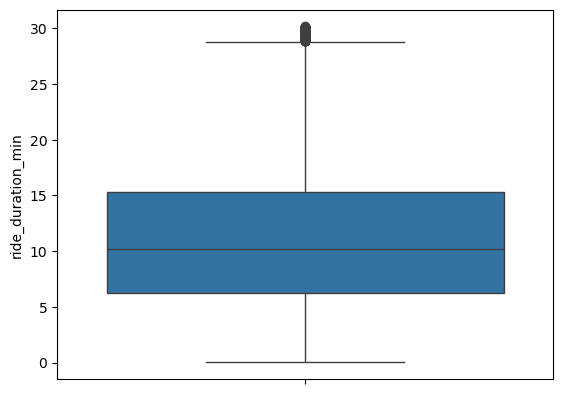

In [345]:
Q1 = data['ride_duration_min'].quantile(0.25)
Q3 = data['ride_duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['ride_duration_min'] >= lower) & (data['ride_duration_min'] <= upper)]
sns.boxplot(data['ride_duration_min'])

<Axes: xlabel='ride_duration_min', ylabel='trip_distance'>

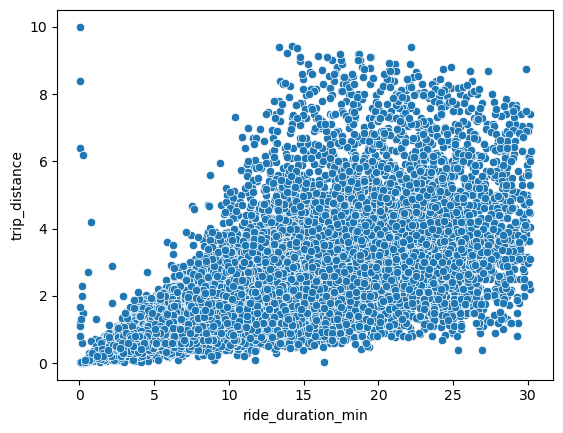

In [ ]:
sns.scatterplot(x=data['ride_duration_min'], y=data['trip_distance'])

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

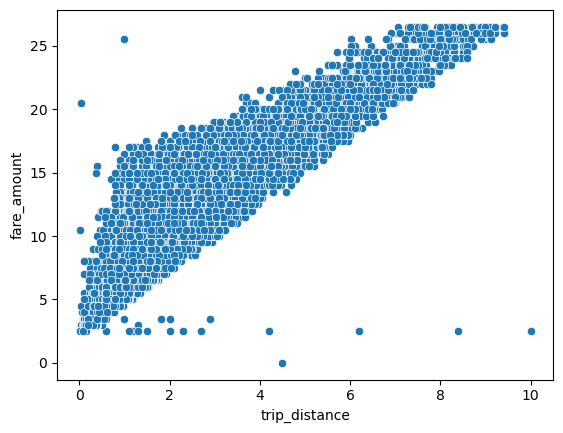

In [347]:
sns.scatterplot(x=data['trip_distance'], y=data['fare_amount'])

<Axes: xlabel='ride_duration_min', ylabel='fare_amount'>

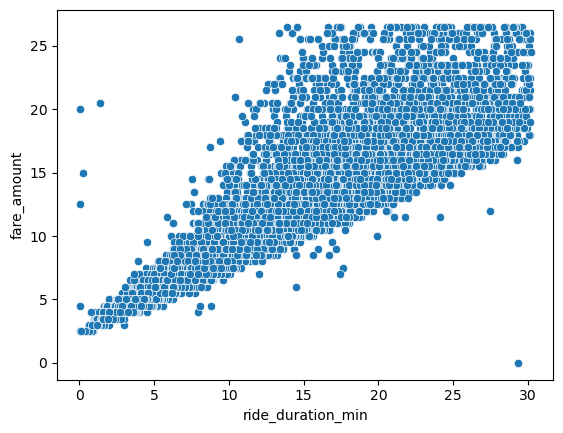

In [ ]:
sns.scatterplot(x=data['ride_duration_min'], y=data['fare_amount'])

#### ⚠️ 이상치 발견!

서로서로 산점도를 그려보니 또 안보이던 이상치들 발견!

1. 주행시간이 거의 0인데 주행거리가 높은 데이터들 발견...
2. 주행거리가 먼데 기본 요금이 그대로...?
3. 주행시간이 30분이나 탔는데 기본 요금이 0에 가까운 데이터 발견... 반대로 기본 요금은 높은데 주행시간이 0에 가까운 데이터들 발견...

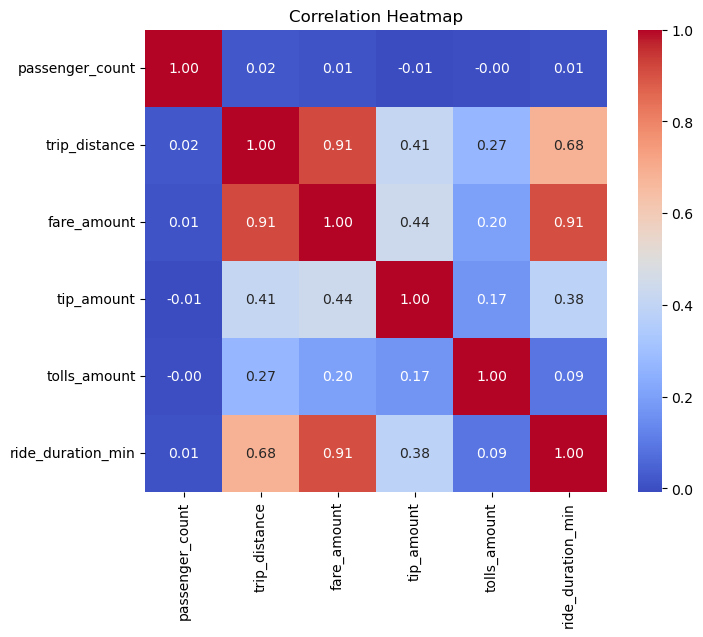

In [349]:
data_num = data[[
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'tip_amount',
    'tolls_amount',
    'ride_duration_min'
]]

corr = data_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,      
    fmt=".2f",       
    cmap="coolwarm", 
    square=True
)
plt.title("Correlation Heatmap")
plt.show()

#### 🚨 이상치 한번더 제거해보자
1. 주행시간이 거의 0인데 주행거리가 높은 데이터들 발견...

In [365]:
bad_case1 = ((data['ride_duration_min'] < 1) & (data['trip_distance'] > 1))

2. 주행거리가 먼데 기본 요금이 그대로...?

In [356]:
bad_case2 = ((data['trip_distance'] > 5) & (data['fare_amount'] < 5))

3. 주행시간이 30분이나 탔는데 기본 요금이 0에 가까운 데이터 발견... 반대로 기본 요금은 높은데 주행시간이 0에 가까운 데이터들 발견...

In [357]:
bad_case3 = (
    ((data['ride_duration_min'] > 25) & (data['fare_amount'] < 5)) |
    ((data['fare_amount'] > 10) & (data['ride_duration_min'] < 5))
)

In [366]:
bad_mask = bad_case1 | bad_case2 | bad_case3
bad_mask.sum()

np.int64(16)

In [367]:
data[bad_mask][['ride_duration_min', 'trip_distance', 'fare_amount']].head()

,ride_duration_min,trip_distance,fare_amount
1077,0.15,2.3,2.50
2225,0.05,10.0,2.50
3553,0.25,1.5,15.00
4063,29.35,4.5,0.01
5680,0.25,1.5,2.50


In [360]:
data_clean = data[~bad_mask]

<Axes: xlabel='ride_duration_min', ylabel='trip_distance'>

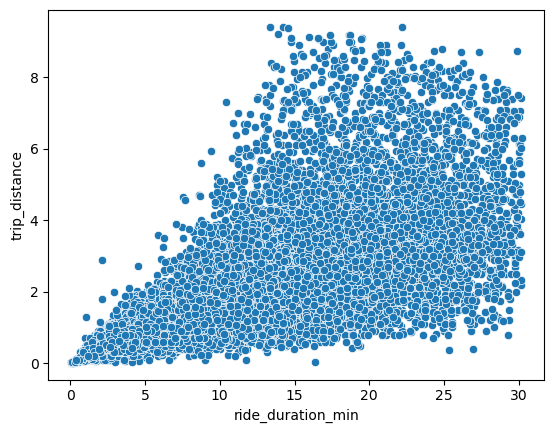

In [ ]:
sns.scatterplot(x=data_clean['ride_duration_min'], y=data_clean['trip_distance'])

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

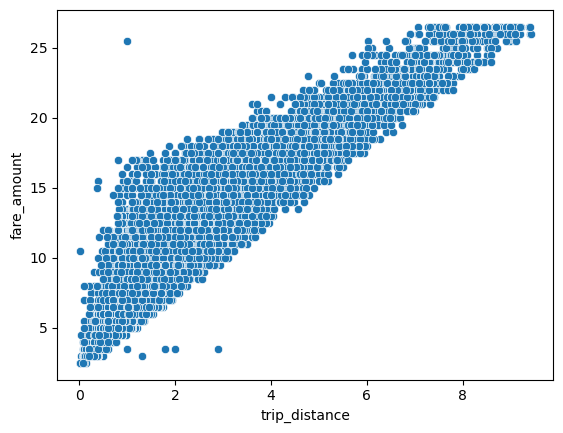

In [363]:
sns.scatterplot(x=data_clean['trip_distance'], y=data_clean['fare_amount'])

<Axes: xlabel='ride_duration_min', ylabel='fare_amount'>

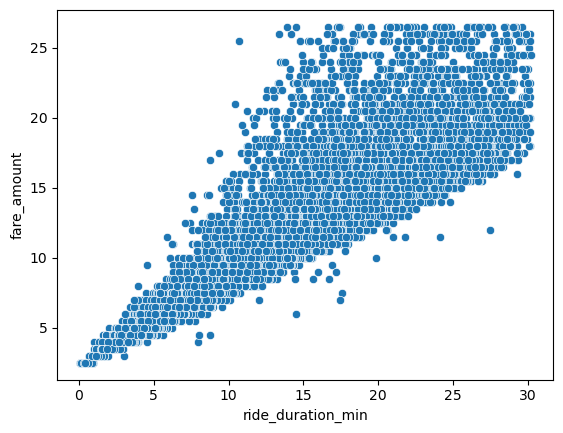

In [ ]:
sns.scatterplot(x=data_clean['ride_duration_min'], y=data_clean['fare_amount'])

그래도 전보다는 조금 정리된 그래프를 확인할 수 있었음...  
완전 마음에 들진 않지만... 그래두...ㅎ

## 5. Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들기

In [350]:
data.head(10)

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,ride_duration_min
0,Pamela Duffy,2017-03-25 08:55:43,2017-03-25 09:09:47,Debit Card,6,3.34,13.0,2.76,0.0,14.066667
1,Michelle Foster,2017-04-11 14:53:28,2017-04-11 15:19:58,Debit Card,1,1.80,16.0,4.00,0.0,26.500000
2,Tina Combs,2017-12-15 07:26:56,2017-12-15 07:34:08,Debit Card,1,1.00,6.5,1.45,0.0,7.200000
4,Brianna Johnson,2017-04-15 23:32:20,2017-04-15 23:49:03,Debit Card,1,4.37,16.5,0.00,0.0,16.716667
5,Justin Smith,2017-03-25 20:34:11,2017-03-25 20:42:11,Debit Card,6,2.30,9.0,2.06,0.0,8.000000
7,Hannah Foley,2017-08-15 17:41:06,2017-08-15 18:03:05,Debit Card,1,2.98,16.0,1.78,0.0,21.983333
8,Katie Whitney,2017-02-04 16:17:07,2017-02-04 16:29:14,Cash,1,1.20,9.0,0.00,0.0,12.116667
9,Amanda Jones,2017-11-10 15:20:29,2017-11-10 15:40:55,Cash,1,1.60,13.0,2.75,0.0,20.433333
10,Cory Jensen,2017-03-04 11:58:00,2017-03-04 12:13:12,Cash,1,1.77,11.5,2.46,0.0,15.200000
12,Ryan Reyes,2017-06-09 19:00:26,2017-06-09 19:20:11,Debit Card,1,3.00,15.0,3.35,0.0,19.750000


In [351]:
data['payment_method'].value_counts()

payment_method
Cash           9814
Debit Card     5087
Credit Card    5015
Name: count, dtype: int64

In [352]:
data['payment_method'] = data['payment_method'].replace(['Credit Card', 'Debit Card'],'Card')

In [353]:
data['payment_method'].value_counts()

payment_method
Card    10102
Cash     9814
Name: count, dtype: int64